# Lab 5: Spatial Filtering – Smoothing and Sharpening

### Student **Nawaf Rabea Shahbal 2240009025**

## Loading the Images

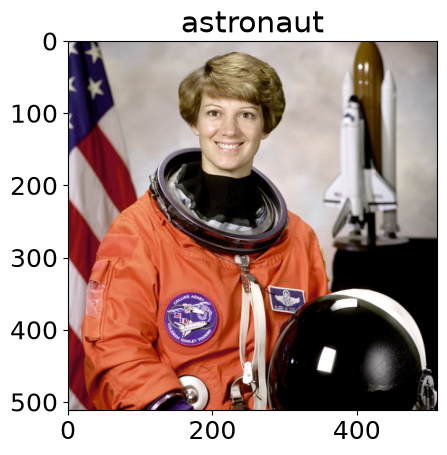

C:\Users\pZwZ\AppData\Local\Temp\ipykernel_19804\494984274.py:44: UserWarning: saved_images\binary_blobs.png is a boolean image: setting True to 255 and False to 0. To silence this warning, please convert the image using img_as_ubyte.
  ski.io.imsave(file_path, image)


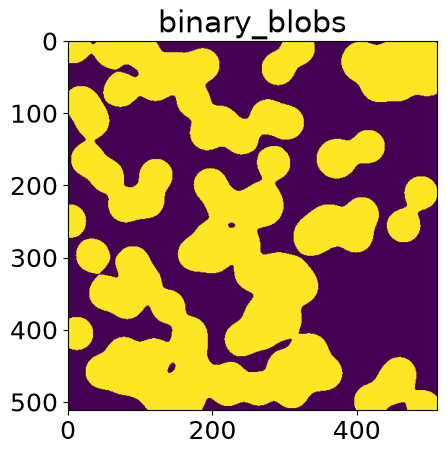

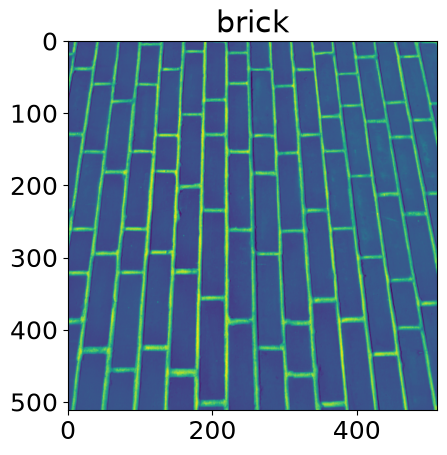

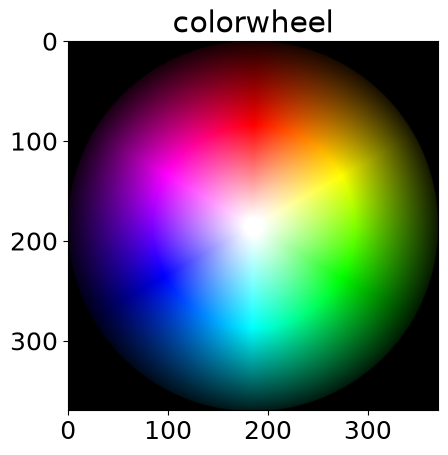

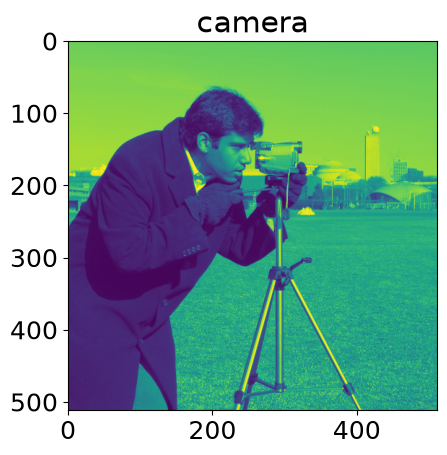

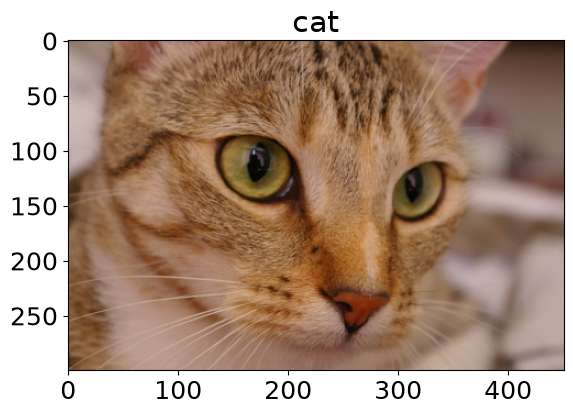

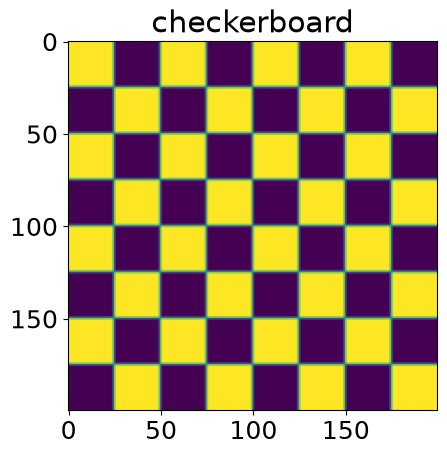

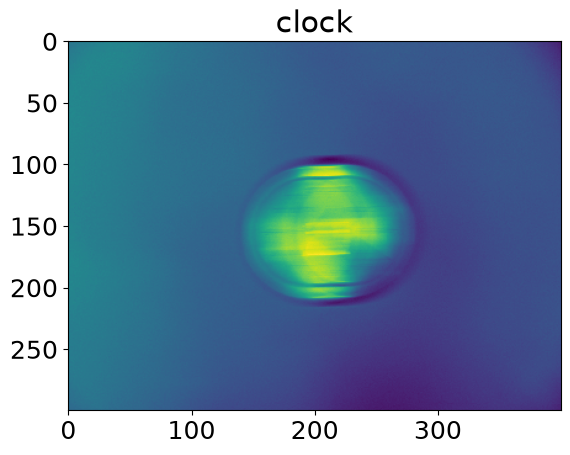

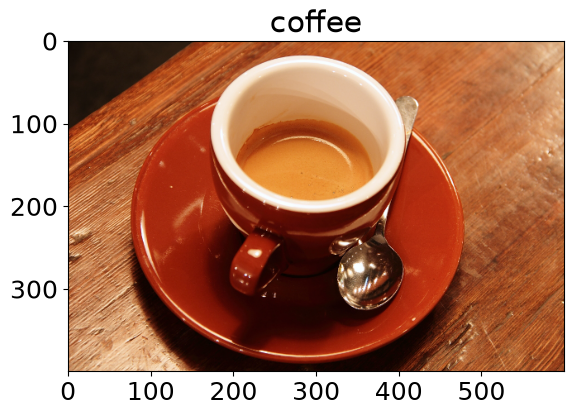

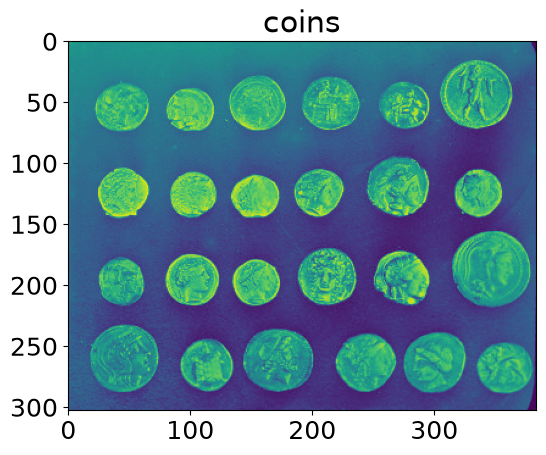

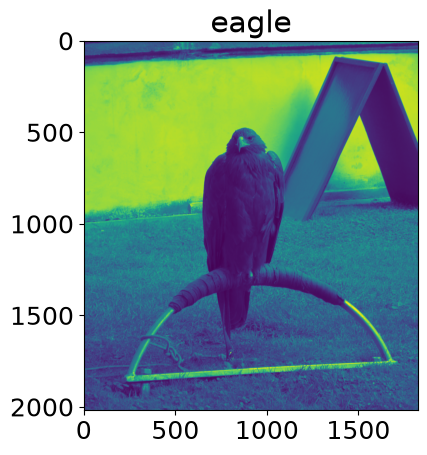

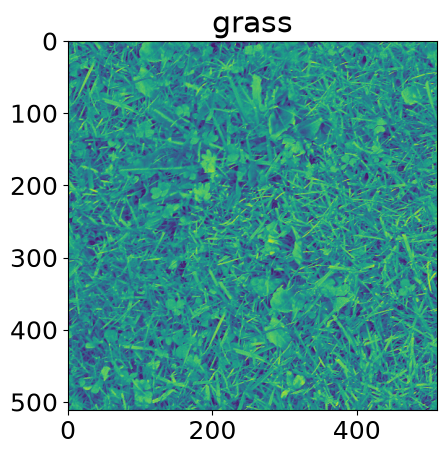

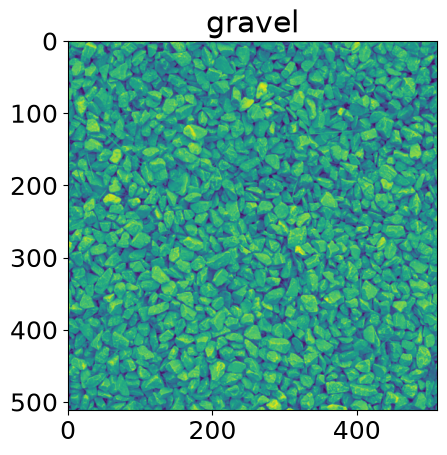

C:\Users\pZwZ\AppData\Local\Temp\ipykernel_19804\494984274.py:44: UserWarning: saved_images\horse.png is a boolean image: setting True to 255 and False to 0. To silence this warning, please convert the image using img_as_ubyte.
  ski.io.imsave(file_path, image)


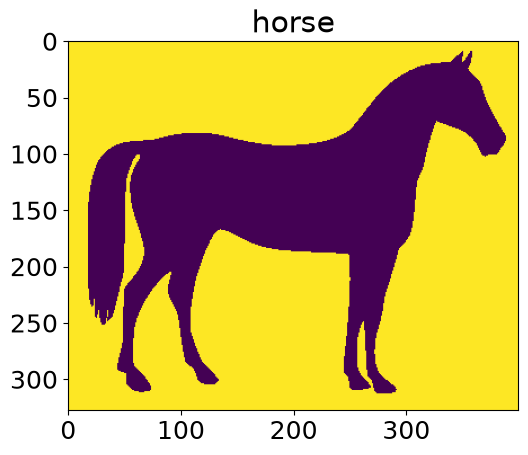

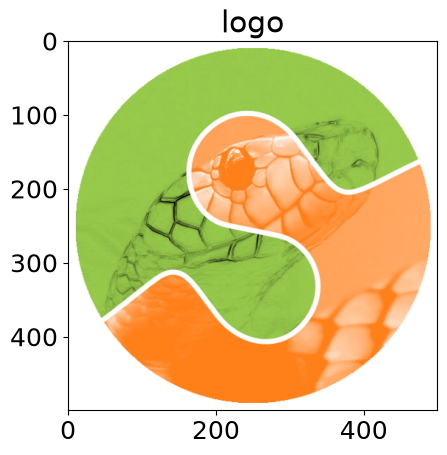

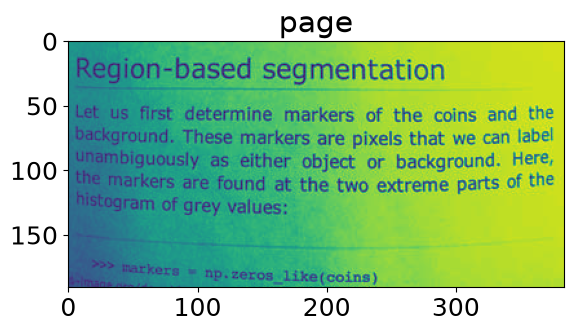

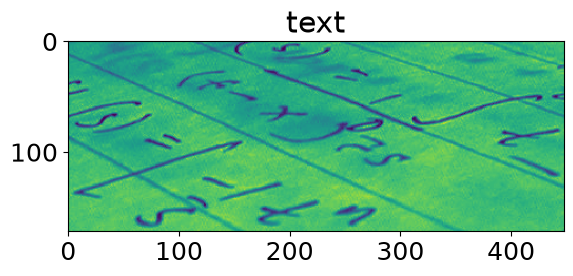

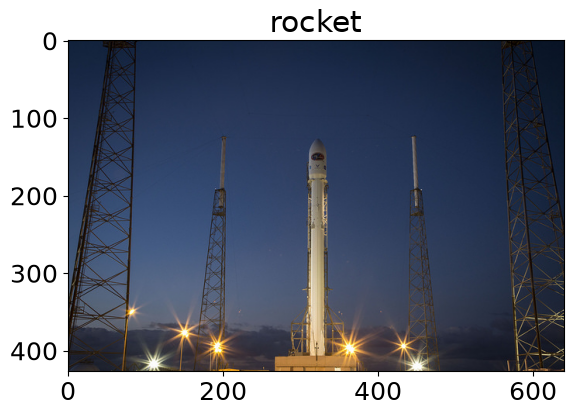

In [ ]:
import os
import cv2
from skimage import data, img_as_float, exposure, io
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import skimage as ski

matplotlib.rcParams['font.size'] = 18

images = (
    'astronaut',
    'binary_blobs',
    'brick',
    'colorwheel',
    'camera',
    'cat',
    'checkerboard',
    'clock',
    'coffee',
    'coins',
    'eagle',
    'grass',
    'gravel',
    'horse',
    'logo',
    'page',
    'text',
    'rocket',
)


# . Define the folder name and create it if it doesn't exist
output_folder = "images"
os.makedirs(output_folder, exist_ok=True)

# . Iterate through your images and save them
for name in images: # Assuming 'images' list is defined earlier
    caller = getattr(ski.data, name)
    image = caller()
    
    # Save the image to the folder
    file_path = os.path.join(output_folder, f"{name}.png")
    ski.io.imsave(file_path, image)
    
    # Display the image as you did before
    plt.figure()
    plt.title(name)
    plt.imshow(image)
    plt.show()

    

## Images Are Saved in the Folder Now



### Task 1 UNSHARP

In [12]:
image = cv2.imread('images/cat.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Convert from BGR to RGB
# Gaussian sigma
sigma=2
#parameter
amount=1.5
# Convert image to float32 for processing
image_float = image.astype(np.float32) / 255.0
# Apply Gaussian blur
blurred = cv2.GaussianBlur(image_float, (0, 0), sigmaX=sigma,
sigmaY=sigma)
# Perform Unsharp Masking
sharpened = np.clip(image_float + amount * (image_float - blurred), 0, 1)

# Plot original, blurred, and sharpened images
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image)
ax[0].set_title("Original Image")
ax[0].axis("off")
ax[1].imshow(blurred)
ax[1].set_title("Blurred Image")
ax[1].axis("off")
ax[2].imshow(sharpened)
ax[2].set_title("Sharpened (Unsharp Masking)")
ax[2].axis("off")
plt.show()


error: OpenCV(5.0.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'
